In [1]:
%load_ext autoreload
%autoreload 2
%env CUPY_ACCELERATORS=cutensor,cub
import tensorly as tl
import plotly.io as pio
pio.renderers.default = 'iframe'
#tl.set_backend('cupy')
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()
print(f'TensorLy backend: {tl.get_backend()}')
print(f'TensorLy tenalg backend: {tl.tenalg.get_backend()}')

env: CUPY_ACCELERATORS=cutensor,cub
TensorLy backend: numpy
TensorLy tenalg backend: einsum


In [2]:
from moabb.paradigms import FilterBankMotorImagery
from moabb.datasets import *
from hoda.tensorize import fh_power, fh_log_envelope
from hoda.classification import ZLogRatio, ZScore
dataset = AlexMI()

paradigm = FilterBankMotorImagery(n_classes=len(dataset.event_id), resample=250)
X, y, meta = paradigm.get_data(
     dataset=dataset, 
     subjects=[1],
)
print(X.shape)
X = fh_power(X, sfreq=250, target_sfreq=16)
X = tl.tensor(X)
X = ZLogRatio().fit_transform(X)
X = ZScore().fit_transform(X)
X.shape

Choosing from all possible events
/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>

/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>

/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>

/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 60 event

(60, 16, 750, 6)


(60, 6, 16, 50)

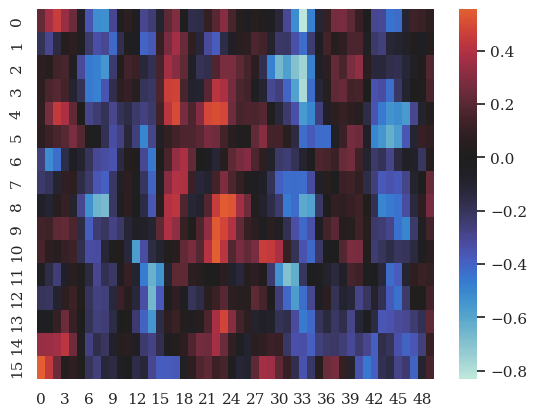

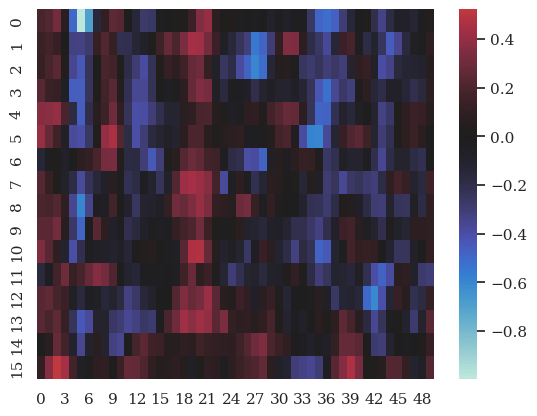

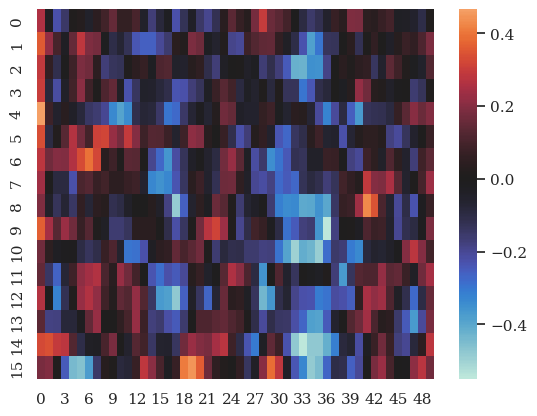

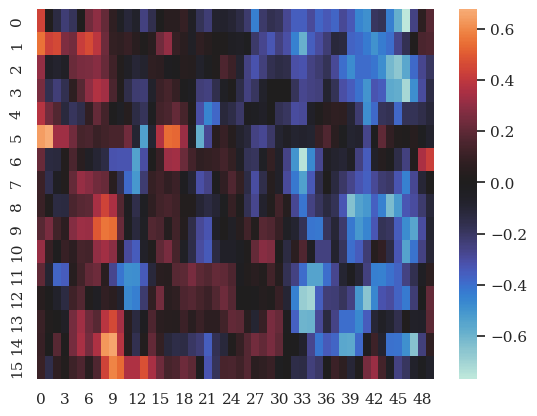

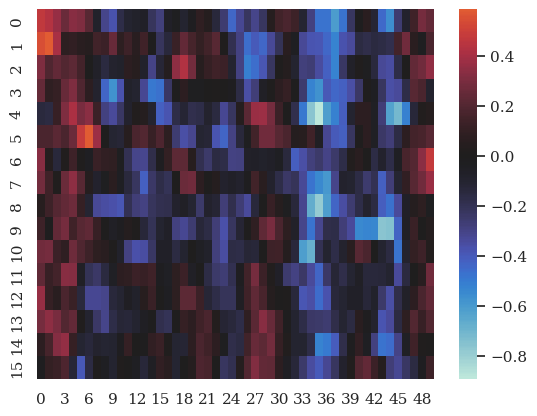

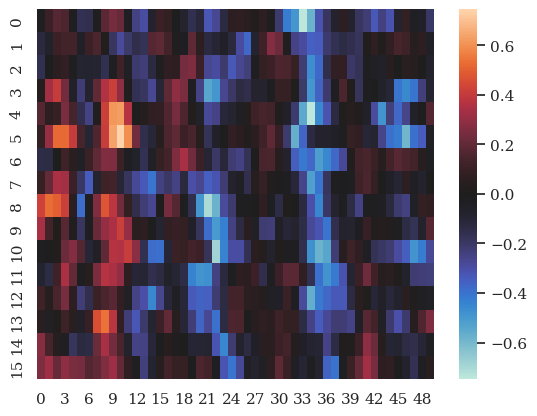

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

x_right_hand = X[y=='right_hand'].mean(axis=0)
x_rest = X[y=='rest'].mean(axis=0)
x_feet = X[y=='feet'].mean(axis=0)
x_mean = X.mean(axis=0)
for f in range(x_right_hand.shape[0]):
    sns.heatmap(x_right_hand[f], center=0)
    plt.show()

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd

x = X.flatten()
x = tl.to_numpy(x)
hist, bin_edges = np.histogram(x, bins=100000)
bins = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute the mean of each subsequent pair
df = pd.DataFrame({'bins':bins, 'count':hist})
px.histogram(df, x="bins", y="count")

In [5]:
from hoda.hoda import HODA

hoda = HODA(
        rank=None,
        max_iter=256,
        tol=1e-6,
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        forward=True,
        theta=0.3,
        refit_shrinkage=True,
)


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from hoda.util import solve_gevdh

plt.style.use('default')
%load_ext line_profiler

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


Backward HODA model rank=(2, 1, 4):  57%|█████▋    | 147/256 [00:00<00:00, 171.54it/s]


,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.491913e+00,0.188482,99765.579437
1,1,2,2,7.538447e-01,0.024275,69291.554876
2,1,3,3,1.309417e+00,0.170544,56808.645055
3,2,1,4,8.936420e-02,0.526969,101199.116678
4,2,2,5,3.304293e-01,0.020129,38997.129883
...,...,...,...,...,...,...
439,147,2,440,5.640934e-07,0.075753,10488.990258
440,147,3,441,1.007802e-06,0.233616,20701.597475
441,148,1,442,3.332640e-07,0.590935,102218.435413
442,148,2,443,5.130351e-07,0.075753,10488.990058


In [7]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.491913e+00,0.188482,99765.579437
1,1,2,2,7.538447e-01,0.024275,69291.554876
2,1,3,3,1.309417e+00,0.170544,56808.645055
3,2,1,3,8.936420e-02,0.526969,101199.116678
4,2,2,4,3.304293e-01,0.020129,38997.129883
...,...,...,...,...,...,...
439,147,2,294,5.640934e-07,0.075753,10488.990258
440,147,3,295,1.007802e-06,0.233616,20701.597475
441,148,1,295,3.332640e-07,0.590935,102218.435413
442,148,2,296,5.130351e-07,0.075753,10488.990058


In [8]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr', log_y=False)
    fig.show()

In [9]:
px.line(df, x='iteration', y='update', log_y=True, color='mode')


In [10]:
px.line(df, x='flip', y='shrinkage', log_y=False, color='mode')

In [11]:
px.line(df, x='flip', y='objective', log_y=False, color='mode')

In [12]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model :  26%|██▌       | 66/255 [00:00<00:00, 499.86it/s]


,iteration,mode,flip,update,lambda_
0,1,1,1,1.589011e-01,0.0
1,1,2,2,2.153047e+00,0.0
2,1,3,3,2.754186e+00,0.0
3,2,1,4,2.520974e-01,0.0
4,2,2,5,1.750387e-01,0.0
...,...,...,...,...,...
196,66,2,197,1.319191e-07,0.0
197,66,3,198,1.016714e-06,0.0
198,67,1,199,5.236916e-07,0.0
199,67,2,200,1.027680e-07,0.0


In [13]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,flip,update,lambda_
0,1,1,1,1.589011e-01,0.0
1,1,2,2,2.153047e+00,0.0
2,1,3,3,2.754186e+00,0.0
3,2,1,3,2.520974e-01,0.0
4,2,2,4,1.750387e-01,0.0
...,...,...,...,...,...
196,66,2,132,1.319191e-07,0.0
197,66,3,133,1.016714e-06,0.0
198,67,1,133,5.236916e-07,0.0
199,67,2,134,1.027680e-07,0.0


In [14]:
if hoda.extra_train_info:
    x.line(df, x='flip', y='mse', log_y=True)

In [15]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

In [16]:
from sklearn.feature_selection import SelectFpr, SelectFwe, SelectFdr
import numpy as np

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFdr(alpha=.05)
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'p_value': select.pvalues_,
    'significant': select.get_support()
})
df

,feature,F,p_value,significant
0,0,3.258981,4.569635e-02,False
1,1,41.059228,9.035830e-12,True
2,2,35.831682,8.374687e-11,True
3,3,30.582558,9.473028e-10,True
4,4,37.414525,4.189058e-11,True
5,5,0.223095,8.007341e-01,False
6,6,32.270027,4.245508e-10,True
7,7,54.035188,6.900219e-14,True


In [17]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [18]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
x_viz = PCA(n_components=2).fit_transform(xt, y)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)
fig.update_layout(width=1000, height=800)